# Trash Classification using MobileNetV2

This project aims to train an image classifier using the TrashNet dataset.

Goals:
1. Train a lightweight CNN using MobileNetV2
2. Evaluate its performance
3. Convert the model to TensorFlow Lite
4. Deploy the model on a Raspberry Pi with a USB camera


In [24]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pathlib
import os

In [25]:
#Image configuration
IMG_SIZE = 224

#Training configuration
BATCH_SIZE = 32
EPOCHS = 10

#Dataset directories
DATASET_DIR = "dataset/train"
VAL_DIR = "dataset/val"
TEST_DIR = "dataset/test"

In [26]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 1766 files belonging to 6 classes.


Found 503 files belonging to 6 classes.
Found 258 files belonging to 6 classes.
Classes: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [27]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

In [28]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
])

In [29]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

In [30]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)

x = base_model(x, training=False)

x = tf.keras.layers.GlobalAveragePooling2D()(x)

x = tf.keras.layers.Dense(128, activation="relu")(x)

outputs = tf.keras.layers.Dense(len(class_names), activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)

In [31]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_2 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_2 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [32]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 46s 759ms/step - accuracy: 0.6546 - loss: 0.9029 - val_accuracy: 0.8250 - val_loss: 0.5433
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 749ms/step - accuracy: 0.7978 - loss: 0.5522 - val_accuracy: 0.8489 - val_loss: 0.4920
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 741ms/step - accuracy: 0.8465 - loss: 0.4415 - val_accuracy: 0.8231 - val_loss: 0.5216
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 744ms/step - accuracy: 0.8613 - loss: 0.3779 - val_accuracy: 0.8748 - val_loss: 0.4392
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 742ms/step - accuracy: 0.8720 - loss: 0.3409 - val_accuracy: 0.8469 - val_loss: 0.4357
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 755ms/step - accuracy: 0.8930 - loss: 0.3010 - val_accuracy: 0.8569 - val_loss: 0.3932
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 749ms/step - accuracy: 0.9026 - loss: 0.2681 - val_accuracy: 0.8569 - val_loss: 0.4481
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 753ms/step - accuracy: 0.9043 - loss: 0.2713 - val_accu

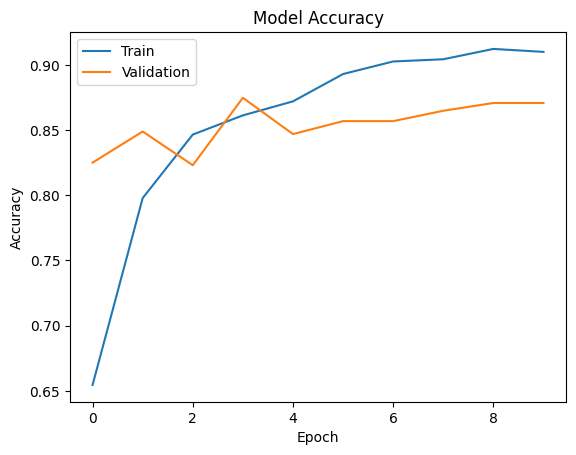

In [33]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.plot(acc)
plt.plot(val_acc)
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'])
plt.show()

In [34]:
loss, acc = model.evaluate(test_ds)

print("Test Accuracy:", acc)

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 485ms/step - accuracy: 0.8527 - loss: 0.4172
Test Accuracy: 0.8527131676673889


In [35]:
model.save("trash_classifier.h5")

In [36]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)

converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open("trash_classifier.tflite", "wb") as f:
    f.write(tflite_model)

print("TensorFlow Lite model saved.")

INFO:tensorflow:Assets written to: /tmp/tmp6m4zht99/assets


INFO:tensorflow:Assets written to: /tmp/tmp6m4zht99/assets


Saved artifact at '/tmp/tmp6m4zht99'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_486')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  139715757125712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139715757121104: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139715757123024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139718581448976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139715757123216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139715757125520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139715757121296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139715757121488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139715757126288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139715757118032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  1397157571

W0000 00:00:1773285620.051819  142113 tf_tfl_flatbuffer_helpers.cc:364] Ignored output_format.
W0000 00:00:1773285620.052874  142113 tf_tfl_flatbuffer_helpers.cc:367] Ignored drop_control_dependency.
I0000 00:00:1773285620.057538  142113 reader.cc:83] Reading SavedModel from: /tmp/tmp6m4zht99
I0000 00:00:1773285620.069028  142113 reader.cc:52] Reading meta graph with tags { serve }
I0000 00:00:1773285620.069053  142113 reader.cc:147] Reading SavedModel debug info (if present) from: /tmp/tmp6m4zht99
I0000 00:00:1773285620.207964  142113 loader.cc:236] Restoring SavedModel bundle.
I0000 00:00:1773285620.928573  142113 loader.cc:220] Running initialization op on SavedModel bundle at path: /tmp/tmp6m4zht99
I0000 00:00:1773285621.128167  142113 loader.cc:471] SavedModel load for tags { serve }; Status: success: OK. Took 1070642 microseconds.


In [37]:
interpreter = tf.lite.Interpreter(model_path="trash_classifier.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(input_details)
print(output_details)

[{'name': 'serving_default_keras_tensor_486:0', 'index': 0, 'shape': array([  1, 224, 224,   3], dtype=int32), 'shape_signature': array([ -1, 224, 224,   3], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
[{'name': 'StatefulPartitionedCall_1:0', 'index': 179, 'shape': array([1, 6], dtype=int32), 'shape_signature': array([-1,  6], dtype=int32), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


/home/vpacalanog/Documents/MIT-IoT/Model/trashnet-env/lib/python3.12/site-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)
